In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import numpy as np
import ast

# =========================================================
# 1. LOAD DATA
# =========================================================
FLOW_FILE        = "../data/output/park_flows_property_10km.csv"
PARKS_AUDIT_FILE = "../data/output/parks_audit.csv"
TRACT_AGG_FILE   = "../data/intermediate/tract_placekey_aggregation.csv"
PK_AGG_FILE      = "../data/intermediate/placekey_tract_aggregation.csv"
TRACT_SHP_PATH   = "../data/raw/census/tl_2023_36_tract.shp"
PARK_PROPS_PATH  = "../data/raw/park_properties/geo_export_d47a2214-9d99-4d6d-b889-0aa5a59bb182.shp"

print("Loading data...")
final_df  = pd.read_csv(FLOW_FILE)
parks_df  = pd.read_csv(PARKS_AUDIT_FILE)
tract_agg = pd.read_csv(TRACT_AGG_FILE)
pk_agg    = pd.read_csv(PK_AGG_FILE)
print(f"Flow rows: {len(final_df)}")
print(f"Audit rows: {len(parks_df)}")


Loading data...
Flow rows: 100851
Audit rows: 2851


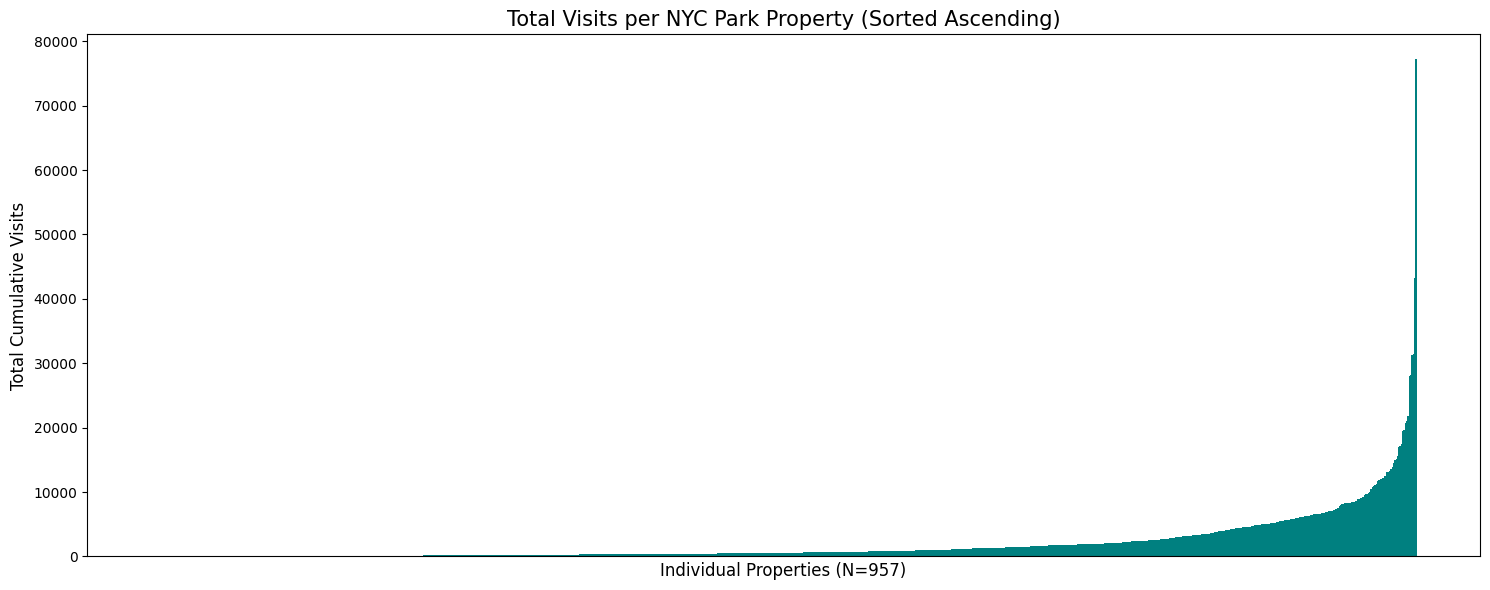

In [12]:
# =========================================================
# 2. VISIT DISTRIBUTION — Properties (Central Park excluded)
# =========================================================
park_visit_totals = (
    final_df[final_df['gis_prop_num'] != 'M010']
    .groupby('gis_prop_num')['visits'].sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(15, 6))
plt.bar(range(len(park_visit_totals)), park_visit_totals.values, width=1.0, color='teal', edgecolor='none')
plt.title('Total Visits per NYC Park Property (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Individual Properties (N={len(park_visit_totals)})', fontsize=12)
plt.ylabel('Total Cumulative Visits', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()


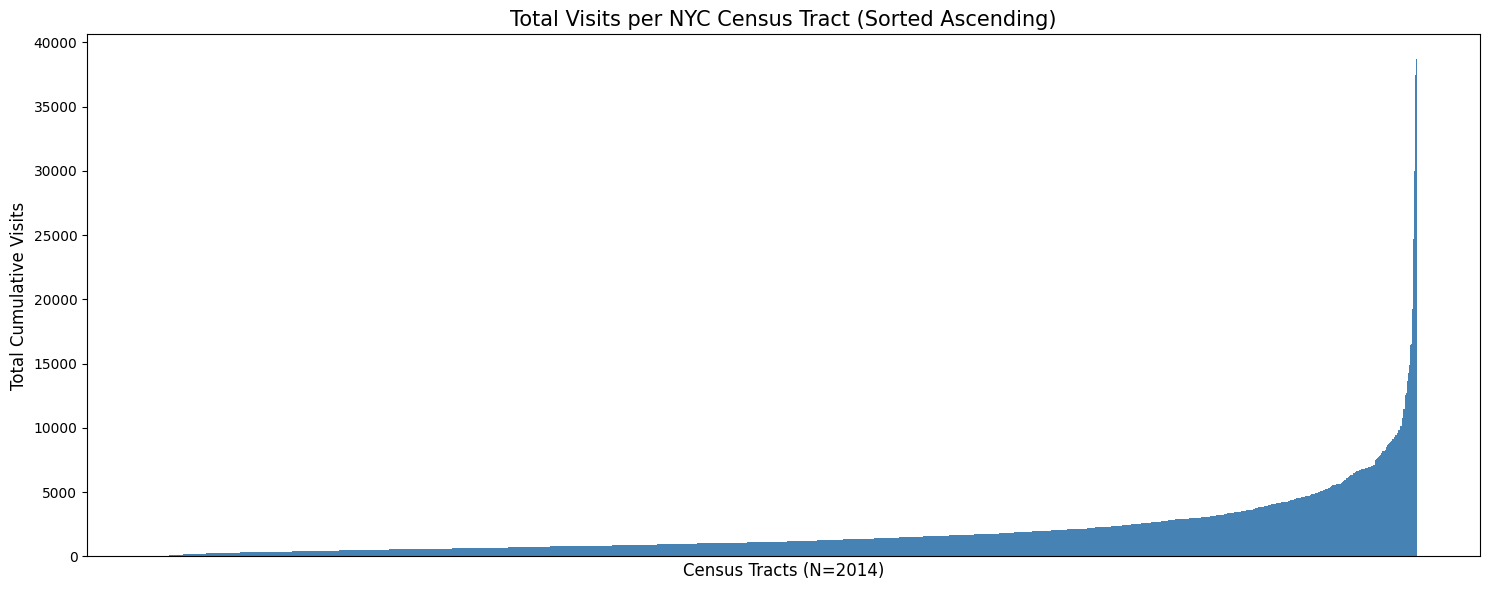

In [13]:
# =========================================================
# 3. VISIT DISTRIBUTION — Tracts
# =========================================================
tract_visit_totals = tract_agg['total_visits'].sort_values(ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.bar(range(len(tract_visit_totals)), tract_visit_totals.values, width=1.0, color='steelblue', edgecolor='none')
plt.title('Total Visits per NYC Census Tract (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Census Tracts (N={len(tract_visit_totals)})', fontsize=12)
plt.ylabel('Total Cumulative Visits', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()


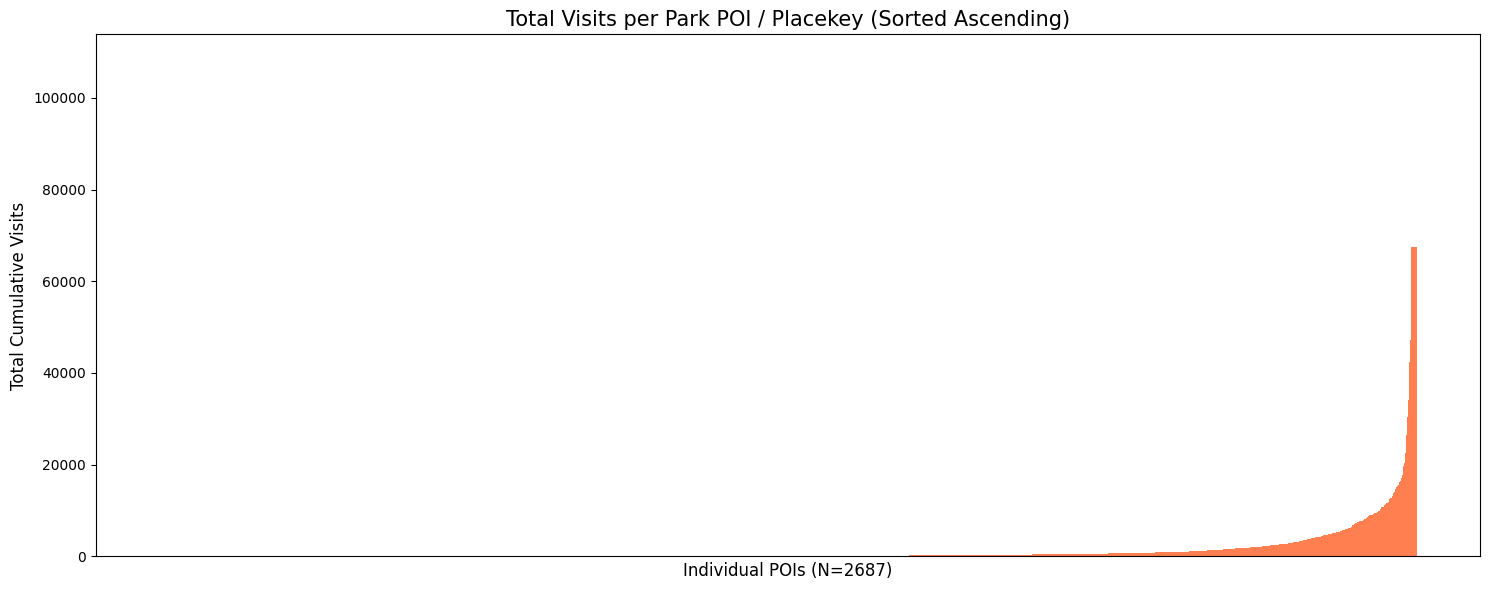

In [14]:
# =========================================================
# 4. VISIT DISTRIBUTION — Placekeys
# =========================================================
pk_visit_totals = pk_agg['total_visits'].sort_values(ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.bar(range(len(pk_visit_totals)), pk_visit_totals.values, width=1.0, color='coral', edgecolor='none')
plt.title('Total Visits per Park POI / Placekey (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Individual POIs (N={len(pk_visit_totals)})', fontsize=12)
plt.ylabel('Total Cumulative Visits', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()


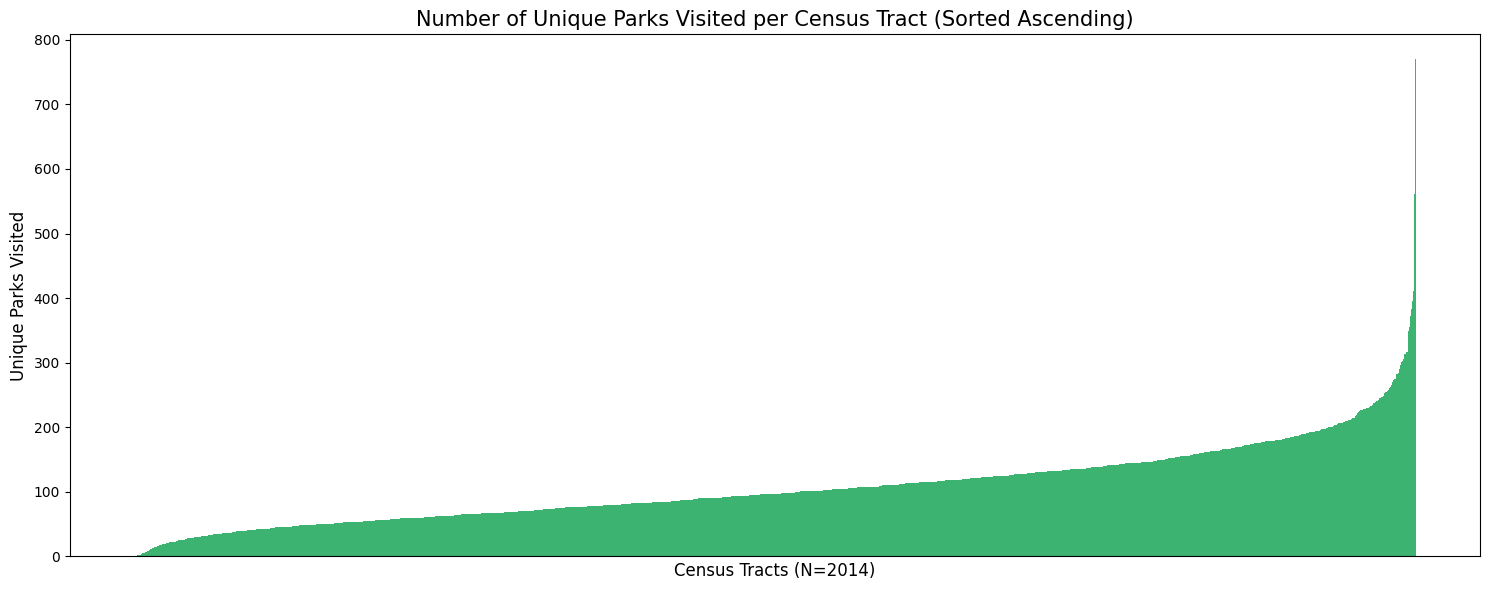

In [15]:
# =========================================================
# 5. TRACT DIVERSITY — Unique parks visited per tract
# =========================================================
tract_agg['num_parks'] = tract_agg['park_visits'].apply(
    lambda x: len(ast.literal_eval(x))
)
num_parks_sorted = tract_agg['num_parks'].sort_values(ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.bar(range(len(num_parks_sorted)), num_parks_sorted.values, width=1.0, color='mediumseagreen', edgecolor='none')
plt.title('Number of Unique Parks Visited per Census Tract (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Census Tracts (N={len(num_parks_sorted)})', fontsize=12)
plt.ylabel('Unique Parks Visited', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()


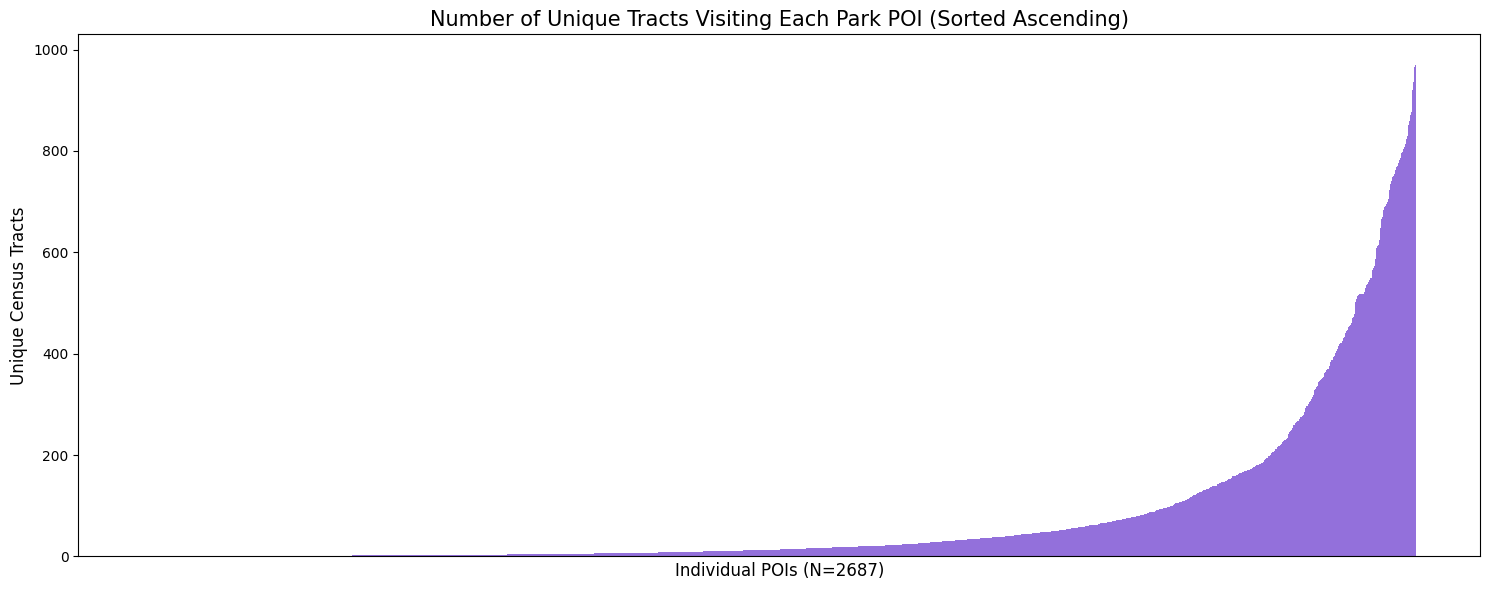

In [16]:
# =========================================================
# 6. POI REACH — Unique tracts per placekey
# =========================================================
pk_agg['num_tracts'] = pk_agg['tract_visits'].apply(
    lambda x: len(ast.literal_eval(x))
)
num_tracts_sorted = pk_agg['num_tracts'].sort_values(ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.bar(range(len(num_tracts_sorted)), num_tracts_sorted.values, width=1.0, color='mediumpurple', edgecolor='none')
plt.title('Number of Unique Tracts Visiting Each Park POI (Sorted Ascending)', fontsize=15)
plt.xlabel(f'Individual POIs (N={len(num_tracts_sorted)})', fontsize=12)
plt.ylabel('Unique Census Tracts', fontsize=12)
plt.xticks([])
plt.tight_layout()
plt.show()


In [17]:
# =========================================================
# 7. TOP 10 MOST VISITED PROPERTIES
# =========================================================
park_rankings = final_df.groupby(['gis_prop_num', 'property_name'])['visits'].sum().reset_index()
top_10 = park_rankings.nlargest(10, 'visits')

prop_attrs = (
    parks_df[['gis_prop_num', 'acres', 'forever_wild_id']]
    .drop_duplicates(subset='gis_prop_num')
)
top_10 = top_10.merge(prop_attrs, on='gis_prop_num', how='left')
top_10 = top_10[[
    'gis_prop_num', 'property_name', 'visits', 'acres', 'forever_wild_id'
]].rename(columns={'visits': 'total_visits'})

print("\n--- Top 10 Most Visited Properties ---")
print(top_10.to_string(index=False))



--- Top 10 Most Visited Properties ---
gis_prop_num              property_name  total_visits   acres forever_wild_id
        B166 Belt Parkway/Shore Parkway         77211 760.430         B166-FW
        M010               Central Park         68631 840.010         M010-FW
        B057                Marine Park         43304 800.000         B057-FW
        M089          Union Square Park         31480   6.510             NaN
       B210W          John J Carty Park         31273   8.565             NaN
        B040           Grand Army Plaza         28221  14.257             NaN
        Q004               Astoria Park         28004  59.956             NaN
        M036              Herald Square         21802   0.210             NaN
       B210D                       Park         21016   1.080             NaN
        M386     Imagination Playground         20685   0.363             NaN


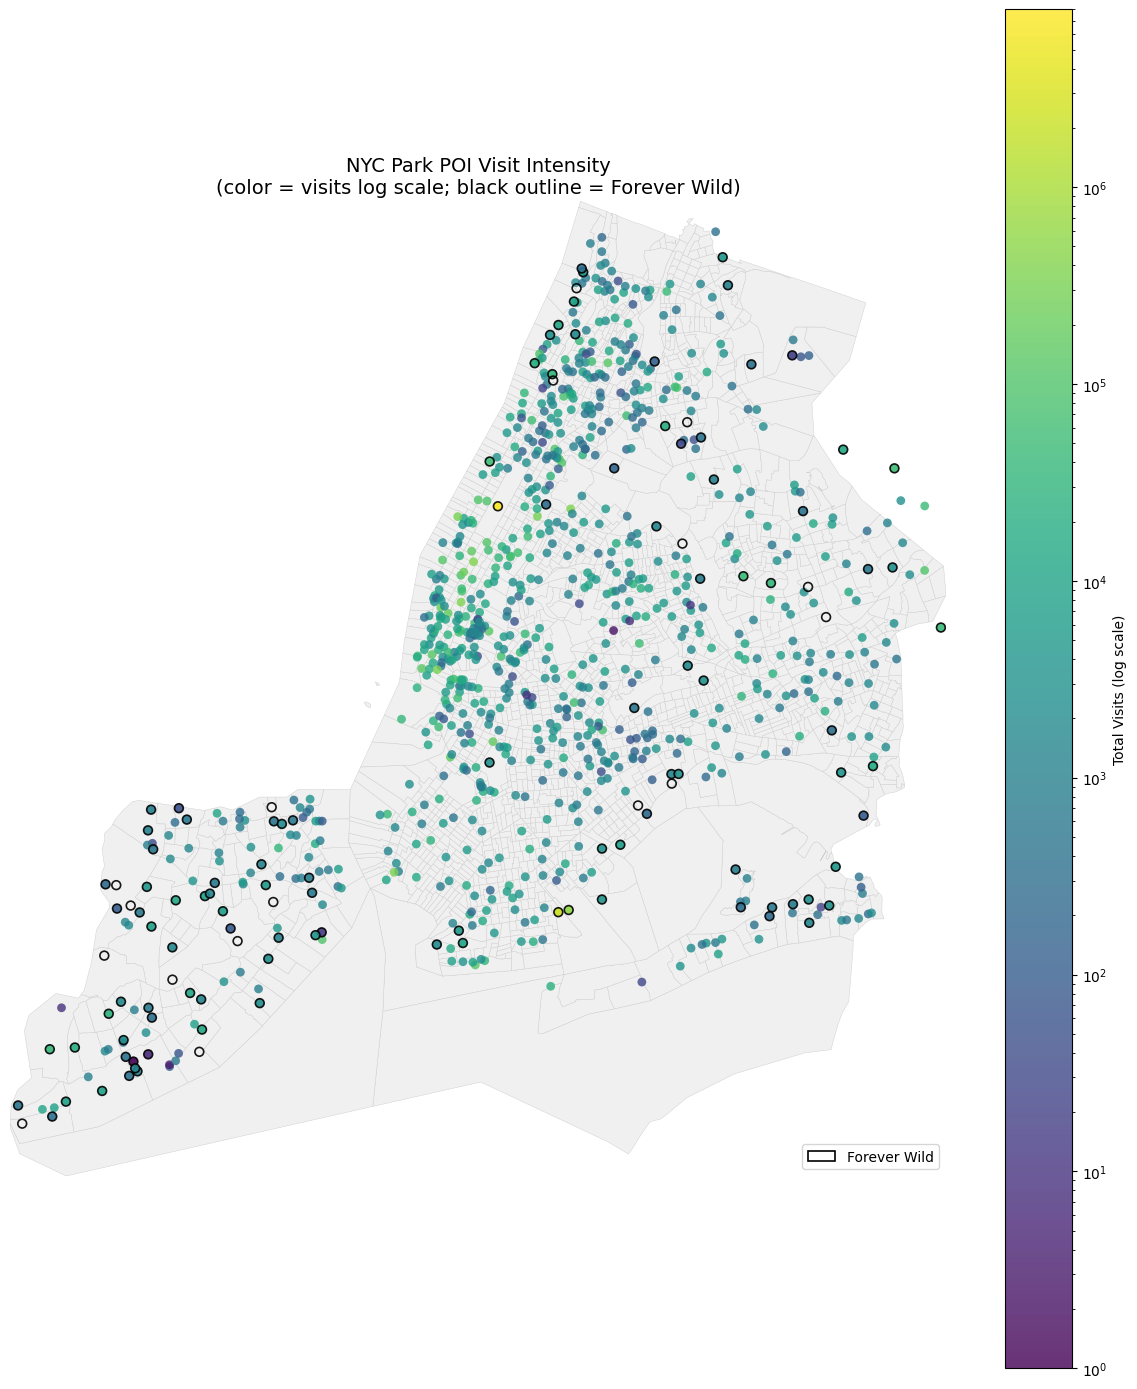

In [18]:
# =========================================================
# 8. POI HEATMAP — Visit intensity by location
# Forever Wild properties indicated with black outline
# =========================================================
import os
import warnings
import matplotlib.colors
warnings.filterwarnings('ignore')

ADVAN_PATH = "../data/raw/advan"
advan_files = [os.path.join(ADVAN_PATH, f) for f in os.listdir(ADVAN_PATH) if f.endswith('.csv')]
coords_list = []
for f in advan_files:
    coords_list.append(pd.read_csv(f, usecols=['PLACEKEY', 'LATITUDE', 'LONGITUDE']).drop_duplicates('PLACEKEY'))
coords = pd.concat(coords_list).drop_duplicates('PLACEKEY').rename(columns={'PLACEKEY': 'placekey'})

poi_map = parks_df[['placekey', 'gis_prop_num', 'visits', 'forever_wild_id']].merge(coords, on='placekey', how='left')
poi_map = poi_map.dropna(subset=['LATITUDE', 'LONGITUDE', 'visits'])

prop_map = poi_map.groupby('gis_prop_num').agg(
    lat=('LATITUDE', 'mean'),
    lon=('LONGITUDE', 'mean'),
    total_visits=('visits', 'sum'),
    forever_wild=('forever_wild_id', lambda x: x.notna().any())
).reset_index()

# Exclude Central Park and top outlier

nyc_counties = ['005', '047', '061', '081', '085']
tracts_shp = gpd.read_file(TRACT_SHP_PATH)
nyc_tracts = tracts_shp[tracts_shp['COUNTYFP'].isin(nyc_counties)].to_crs('EPSG:4326')
minx, miny, maxx, maxy = nyc_tracts.total_bounds

vmin = max(prop_map['total_visits'].min(), 1)
vmax = prop_map['total_visits'].max()
norm = matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(12, 14))
nyc_tracts.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.3)

non_fw = prop_map[~prop_map['forever_wild']]
sc = ax.scatter(
    non_fw['lon'], non_fw['lat'],
    c=non_fw['total_visits'], cmap='viridis',
    norm=norm,
    s=40, alpha=0.8, linewidths=0, zorder=3
)

fw = prop_map[prop_map['forever_wild']]
ax.scatter(
    fw['lon'], fw['lat'],
    c=fw['total_visits'], cmap='viridis',
    norm=norm,
    s=40, alpha=0.9, edgecolors='black', linewidths=1.2, zorder=4
)

plt.colorbar(sc, ax=ax, label='Total Visits (log scale)')
fw_patch = mpatches.Patch(facecolor='white', edgecolor='black', linewidth=1.2, label='Forever Wild')
ax.legend(handles=[fw_patch], loc='lower right', fontsize=10)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title('NYC Park POI Visit Intensity\n(color = visits log scale; black outline = Forever Wild)', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Tracts visiting Prospect Park: 88


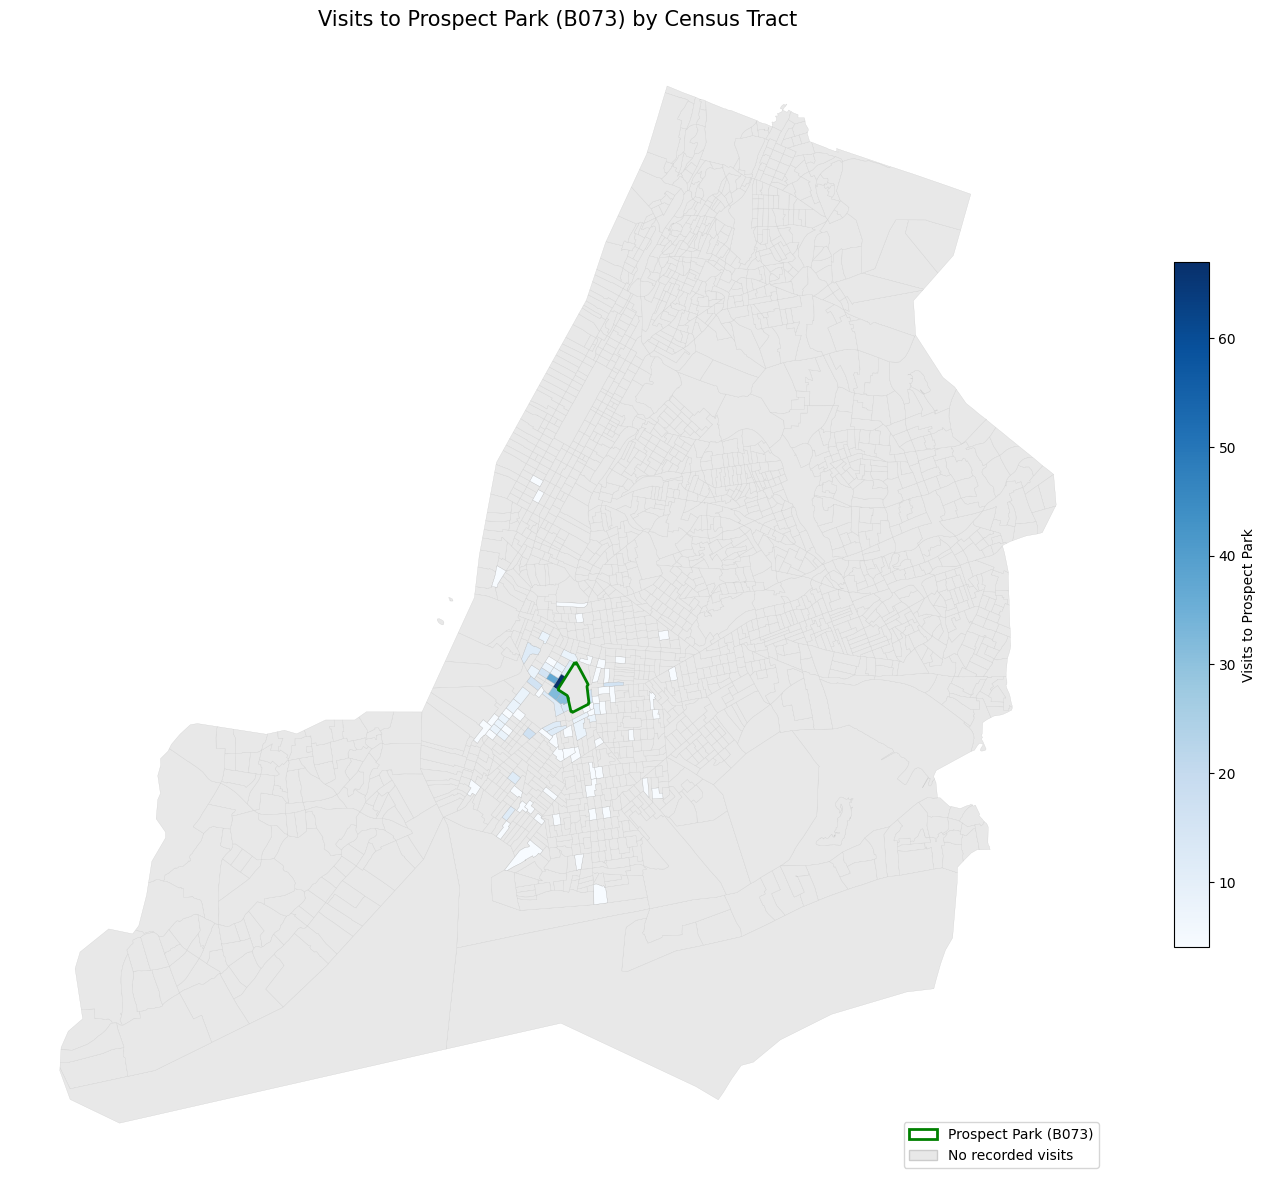

In [19]:
# =========================================================
# 9. CHOROPLETH — Visits to Prospect Park (B073) by tract
# =========================================================
PROSPECT_PROP = 'B073'

# Get all tracts that visit Prospect Park and their visit counts
prospect_flows = final_df[final_df['gis_prop_num'] == PROSPECT_PROP][['tract_i', 'visits']].copy()
prospect_flows['tract_i'] = prospect_flows['tract_i'].astype(str)
print(f"Tracts visiting Prospect Park: {len(prospect_flows)}")

# Load tract shapefile and filter to NYC
tracts = gpd.read_file(TRACT_SHP_PATH)
nyc_counties = ['005', '047', '061', '081', '085']
nyc_tracts = tracts[tracts['COUNTYFP'].isin(nyc_counties)].copy().to_crs('EPSG:4326')
nyc_tracts['GEOID'] = nyc_tracts['GEOID'].astype(str)
nyc_tracts = nyc_tracts.merge(prospect_flows, left_on='GEOID', right_on='tract_i', how='left')

# Load Prospect Park polygon for overlay
parks_shp = gpd.read_file(PARK_PROPS_PATH).to_crs('EPSG:4326')
prospect_poly = parks_shp[parks_shp['gispropnum'] == PROSPECT_PROP].dissolve()

fig, ax = plt.subplots(figsize=(14, 14))

nyc_tracts[nyc_tracts['visits'].isna()].plot(
    ax=ax, color='#e8e8e8', edgecolor='#cccccc', linewidth=0.2
)

nyc_tracts[nyc_tracts['visits'].notna()].plot(
    ax=ax, column='visits', cmap='Blues',
    edgecolor='#aaaaaa', linewidth=0.2,
    legend=True,
    legend_kwds={'label': 'Visits to Prospect Park', 'shrink': 0.5}
)

prospect_poly.plot(ax=ax, color='none', edgecolor='green', linewidth=2, zorder=5)

green_patch = mpatches.Patch(facecolor='none', edgecolor='green', linewidth=2, label='Prospect Park (B073)')
grey_patch  = mpatches.Patch(facecolor='#e8e8e8', edgecolor='#cccccc', label='No recorded visits')
ax.legend(handles=[green_patch, grey_patch], loc='lower right', fontsize=10)

ax.set_title('Visits to Prospect Park (B073) by Census Tract', fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()